In [2]:
import numpy as np

In [3]:
# and gate
X_and=np.array([
    [0,0],[0,1],[1,0],[1,1]
]
)
y_and=np.array([0,0,0,1])
X_and,y_and

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

In [4]:
# or gate
X_or=np.array([
    [0,0],[0,1],[1,0],[1,1]
]
)
y_or=np.array([0,1,1,1])
X_or,y_or

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 1, 1, 1]))

In [5]:
def step_function(z):
    return 1 if z>=0 else 0


In [6]:
def build(X,y):
    w=np.zeros(2)
    b=0
    epochs=10
    learning_rate=0.1
    for epoch in range(epochs):
        for i in range(len(X)):
            # Calculate linear combination
            # Assuming w is a numpy array [w1, w2] and X[i] is [x1, x2]
            z = np.dot(w, X[i]) + b
            
            # Pass through activation function
            y_pred = step_function(z)
            
            # Calculate error: (Target - Predicted)
            error = y[i] - y_pred
            
            # Update weights and bias only if there is an error
            if error != 0:
                w = w + learning_rate * error * X[i]
                b = b + learning_rate * error

    return w,b

In [9]:
w_and,b_and=build(X_and,y_and)
print("And gate operations : ",w_and,b_and)
print("Testing and gate")
for i in range(len(X_and)):
    z=np.dot(w_and,X_and[i])+b_and
    pred=step_function(z)
    print(f"Input :{X_and[i]} ,Prediction : {pred}")

And gate operations :  [0.2 0.1] -0.20000000000000004
Testing and gate
Input :[0 0] ,Prediction : 0
Input :[0 1] ,Prediction : 0
Input :[1 0] ,Prediction : 0
Input :[1 1] ,Prediction : 1


In [11]:
w_or,b_or=build(X_or,y_or)
print("Or gate operations :",w_or,b_or)
print("Testing or gate ")
for i in range(len(X_or)):
    z=np.dot(w_or,X_or[i])+b_or
    pred=step_function(z)
    print(f"Input :{X_or[i]} ,Prediction : {pred}")

Or gate operations : [0.1 0.1] -0.1
Testing or gate 
Input :[0 0] ,Prediction : 0
Input :[0 1] ,Prediction : 1
Input :[1 0] ,Prediction : 1
Input :[1 1] ,Prediction : 1


In [12]:
# xor gate
X_xor=np.array([
    [0,0],[0,1],[1,0],[1,1]
]
)
y_xor=np.array([0,1,1,0])
X_xor,y_xor

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 1, 1, 0]))

In [13]:
w_xor,b_xor=build(X_xor,y_xor)
print("XOR gate operations :",w_xor,b_xor)
print("Testing or gate ")
for i in range(len(X_xor)):
    z=np.dot(w_xor,X_xor[i])+b_xor
    pred=step_function(z)
    print(f"Input :{X_xor[i]} ,Prediction : {pred}")

XOR gate operations : [-0.1  0. ] 0.0
Testing or gate 
Input :[0 0] ,Prediction : 1
Input :[0 1] ,Prediction : 1
Input :[1 0] ,Prediction : 0
Input :[1 1] ,Prediction : 0


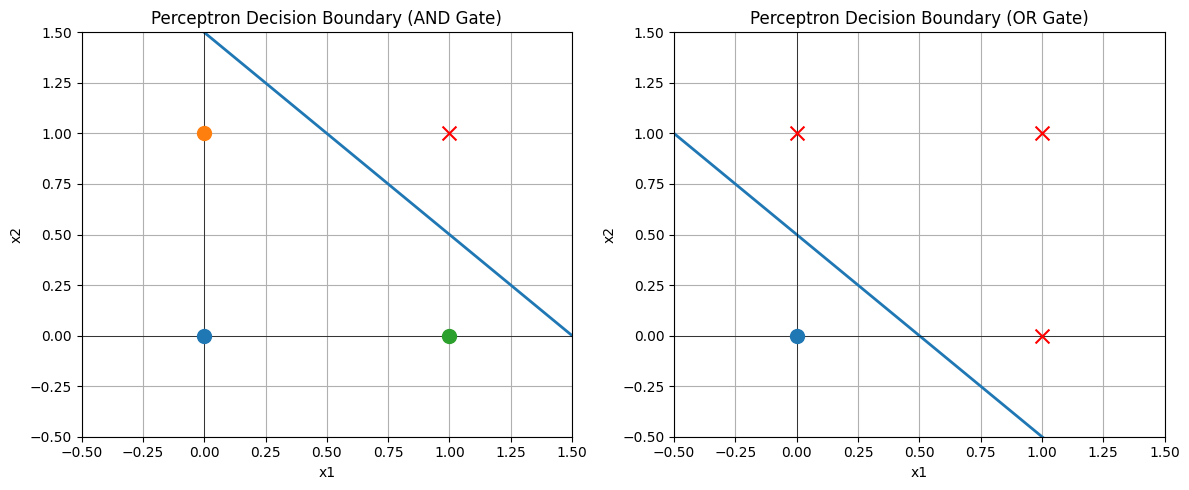

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gate(gate_type, ax):
    # Data points (x1, x2)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    
    if gate_type == 'AND':
        # Labels: Only (1,1) is 1 (True)
        y = np.array([0, 0, 0, 1])
        # Decision boundary: w1*x1 + w2*x2 + b = 0 => 1*x1 + 1*x2 - 1.5 = 0
        # x2 = -x1 + 1.5
        x_vals = np.linspace(-0.5, 1.5, 100)
        y_vals = -x_vals + 1.5
        title = "Perceptron Decision Boundary (AND Gate)"
    else:
        # Labels: (0,0) is 0, others are 1
        y = np.array([0, 1, 1, 1])
        # Decision boundary: 1*x1 + 1*x2 - 0.5 = 0 => x2 = -x1 + 0.5
        x_vals = np.linspace(-0.5, 1.5, 100)
        y_vals = -x_vals + 0.5
        title = "Perceptron Decision Boundary (OR Gate)"

    # Plotting the points
    for i in range(len(y)):
        marker = 'x' if y[i] == 1 else 'o'
        color = 'red' if y[i] == 1 else 'C0' if i==0 else 'C1' if i==1 else 'C2'
        ax.scatter(X[i, 0], X[i, 1], marker=marker, color=color, s=100, zorder=3)

    # Plotting the boundary line
    ax.plot(x_vals, y_vals, label='Decision Boundary', linewidth=2)
    
    # Formatting
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim([-0.5, 1.5])
    ax.set_ylim([-0.5, 1.5])
    ax.grid(True)
    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_gate('AND', ax1)
plot_gate('OR', ax2)

plt.tight_layout()
plt.show()